
# Headless Volume Rendering in **VTK**

This notebook shows how to render 3D volumes with **VTK** in a **headless** setup.

In [1]:

# 1) Imports & output folder
import numpy as np
import imageio.v3 as iio
from pathlib import Path
import matplotlib.pyplot as plt
import tifffile as tiff
import vtk
from vtkmodules.vtkRenderingCore import (
    vtkRenderer, vtkRenderWindow, vtkVolume, vtkVolumeProperty, vtkColorTransferFunction,
    vtkWindowToImageFilter, vtkCamera
)
from vtkmodules.vtkCommonDataModel import vtkPiecewiseFunction
# from vtkmodules.vtkRenderingVolume import vtkSmartVolumeMapper
from vtkmodules.vtkCommonDataModel import vtkImageData
from vtkmodules.vtkIOImage import vtkPNGWriter
from vtkmodules.vtkFiltersCore import vtkFlyingEdges3D, vtkContourFilter
from vtkmodules.vtkRenderingOpenGL2 import vtkOpenGLRenderer
import vtk.util.numpy_support

OUT = Path("results") / "vtk_headless_outputs"
OUT.mkdir(exist_ok=True, parents=True)
print("VTK:", vtk.VTK_VERSION)


VTK: 9.5.2



## 2) Example data loading


In [2]:
vol = tiff.imread(Path("example_data") / "size_512" / "raw_channel3.tif")
vol.shape, vol.dtype, float(vol.min()), float(vol.max())

((512, 512, 512), dtype('float32'), 0.0, 255.0)


## 3) NumPy → vtkImageData


In [11]:

def numpy_to_vtk_image(volume_np, spacing=(1.0,1.0,1.0)):
    assert volume_np.ndim == 3, "Expect (Z, Y, X)"
    z, y, x = volume_np.shape
    img = vtkImageData()
    img.SetDimensions(x, y, z)
    img.SetSpacing(spacing)
    img.AllocateScalars(vtk.VTK_FLOAT, 1)

    vtk_array = vtk.util.numpy_support.numpy_to_vtk(
        num_array=volume_np.ravel(order="F"),
        deep=True,
        array_type=vtk.VTK_FLOAT,
    )
    img.GetPointData().SetScalars(vtk_array)
    return img

vtk_img = numpy_to_vtk_image(vol)
vtk_img

<ImageData(0x5f27d8d4a6e0) at 0x713526fc5540>


## 4) Volume rendering (offscreen)


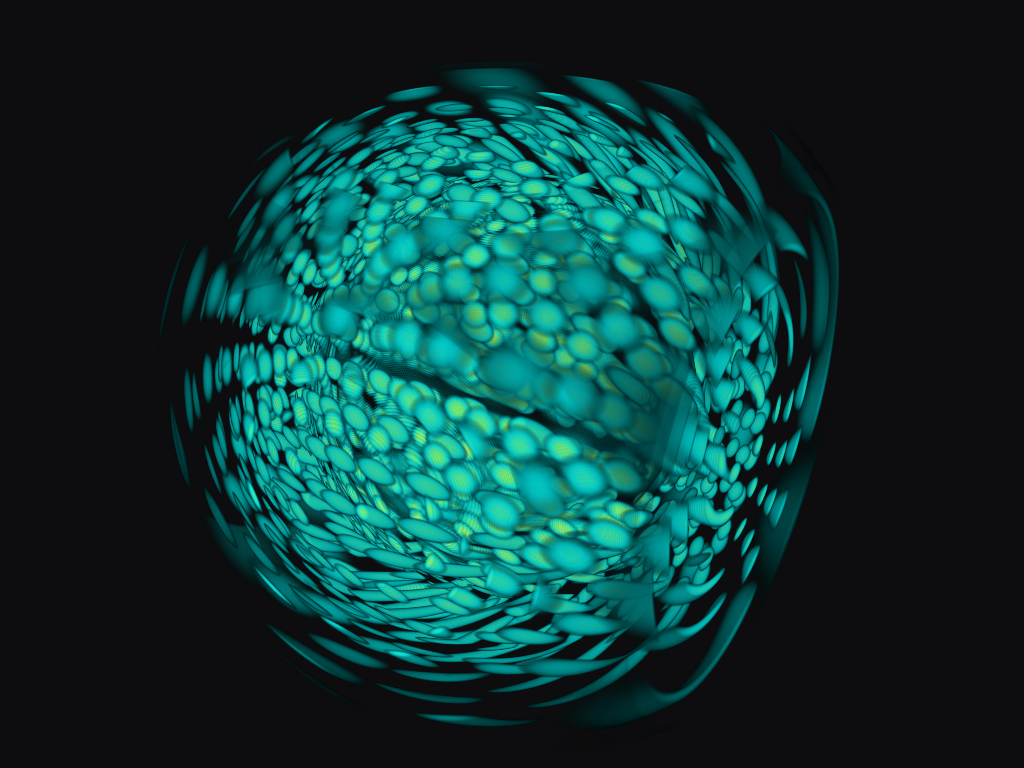

In [23]:

# Transfer functions
color_tf = vtkColorTransferFunction()
color_tf.AddRGBPoint(0.0, 0.0, 0.0, 0.0)
color_tf.AddRGBPoint(100, 0.0, 1.0, 1.0)
color_tf.AddRGBPoint(200, 1.0, 1.0, 0.0)
color_tf.AddRGBPoint(255, 1.0, 1.0, 1.0)

opacity_tf = vtkPiecewiseFunction()
opacity_tf.AddPoint(0.0, 0.0)
opacity_tf.AddPoint(100, 0.6)
opacity_tf.AddPoint(200, 0.9)

prop = vtkVolumeProperty()
prop.SetIndependentComponents(True)
prop.SetColor(color_tf)
prop.SetScalarOpacity(opacity_tf)
prop.SetInterpolationTypeToLinear()
prop.ShadeOff()


mapper = vtk.vtkSmartVolumeMapper()
# mapper = vtk.vtkGPUVolumeRayCastMapper()
mapper.SetInputData(vtk_img)
try:
    mapper.SetRequestedRenderModeToGPU()
except Exception:
    pass

volume_actor = vtkVolume()
volume_actor.SetMapper(mapper)
volume_actor.SetProperty(prop)

renderer = vtkRenderer()
renderer.AddVolume(volume_actor)
renderer.SetBackground(0.05, 0.05, 0.06)

renwin = vtkRenderWindow()
renwin.OffScreenRenderingOn()
renwin.SetSize(1024, 768)
renwin.AddRenderer(renderer)

camera = renderer.GetActiveCamera()
renderer.ResetCamera()
camera.Elevation(30)
camera.Azimuth(30)
camera.Dolly(1.2)
renderer.ResetCameraClippingRange()

def save_png(renwin, path):
    renwin.Render()
    w2i = vtkWindowToImageFilter()
    w2i.SetInput(renwin)
    w2i.Update()
    writer = vtkPNGWriter()
    writer.SetFileName(str(path))
    writer.SetInputConnection(w2i.GetOutputPort())
    writer.Write()

png_basic = OUT / "composite_basic.png"
save_png(renwin, png_basic)
png_basic.as_posix()

from IPython.display import Image
Image(png_basic)


## 5) MIP vs Composite


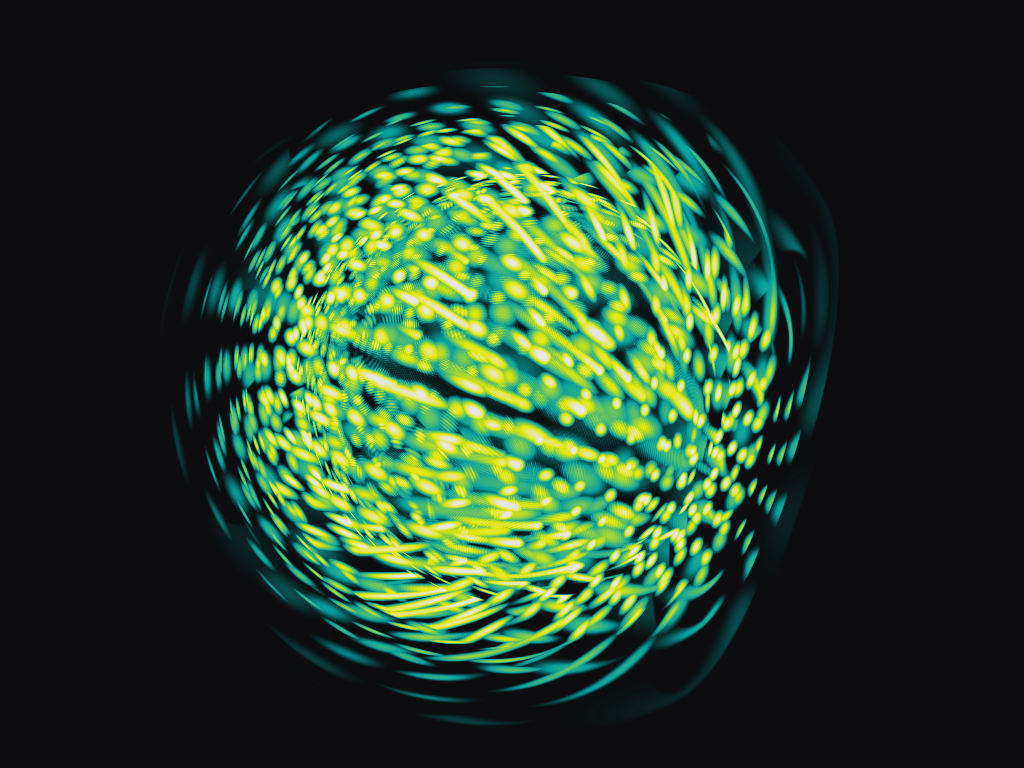

In [24]:

# MIP
mapper.SetBlendModeToMaximumIntensity()
save_png(renwin, OUT / "mip.png")
Image(OUT / "mip.png")


## 8) Spin animation (MP4)


In [26]:

frames = []
for az in range(0, 360, 4):
    camera.Azimuth(4)
    renderer.ResetCameraClippingRange()
    renwin.Render()
    w2i = vtkWindowToImageFilter(); w2i.SetInput(renwin); w2i.Update()
    # Convert to numpy RGBA
    vtk_img_out = w2i.GetOutput()
    w, h = renwin.GetSize()
    arr = vtk.util.numpy_support.vtk_to_numpy(vtk_img_out.GetPointData().GetScalars()).reshape(h, w, -1)
    frames.append(arr.copy())

mp4_path = OUT / "spin.mp4"
iio.imwrite(mp4_path, frames, fps=20)

from IPython.display import Video
Video(mp4_path.as_posix())